In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
df = pd.read_csv(r'C:\Users\rauni\OneDrive\Desktop\Sysslan_Project\Dataset1.csv')
print("Shape:", df.shape)
df.head()

Shape: (186074, 12)


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [6]:
print("Total Records:", len(df))
print("Total Columns:", len(df.columns))
print("Total Trains:", df['Train_No'].nunique())
print("Total Stations:", df['Station_Code'].nunique())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Total Records: 186074
Total Columns: 12
Total Trains: 11113
Total Stations: 8147

Missing Values:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

Duplicates: 0


In [7]:
train_routes = df.groupby('Train_No').agg(
    Start_Station=('Station_Name', 'first'),
    End_Station=('Station_Name', 'last'),
    Total_Stops=('SN', 'count'),
    Total_Distance_km=('Distance', 'max')
).reset_index()

print("Train-wise Route Table:")
train_routes.head(15)

Train-wise Route Table:


,Train_No,Start_Station,End_Station,Total_Stops,Total_Distance_km
0,107,SAWANTWADI R,MADGOAN JN.,4,78
1,108,MADGOAN JN.,SAWANTWADI R,4,83
2,128,MADGOAN JN.,CHHATRAPATI,22,978
3,290,DELHI-SAFDAR,DELHI-SAFDAR,14,2694
4,401,AURANGABAD,VARANASI JN.,12,1618
5,421,LUCKNOW JN.,SHRI MATA VA,5,1276
6,422,SHRI MATA VA,LUCKNOW JN.,5,1277
7,477,SIRSA,SIRSA,14,2616
8,502,RAJENDRANAGA,AMBALA CANTT,9,1206
9,504,PATNA JN.,BATHINDA JN,3,1313


In [8]:
dist_stats = train_routes['Total_Distance_km'].describe()
stops_stats = train_routes['Total_Stops'].describe()

print("Distance (km) Statistics:")
print(f"  Mean   : {dist_stats['mean']:.2f} km")
print(f"  Median : {dist_stats['50%']:.2f} km")
print(f"  Min    : {dist_stats['min']:.2f} km")
print(f"  Max    : {dist_stats['max']:.2f} km")
print(f"  Std Dev: {dist_stats['std']:.2f} km")

print("\nNumber of Stops Statistics:")
print(f"  Mean   : {stops_stats['mean']:.2f}")
print(f"  Median : {stops_stats['50%']:.2f}")
print(f"  Min    : {stops_stats['min']:.0f}")
print(f"  Max    : {stops_stats['max']:.0f}")
print(f"  Std Dev: {stops_stats['std']:.2f}")

Distance (km) Statistics:
  Mean   : 348.87 km
  Median : 82.00 km
  Min    : 1.00 km
  Max    : 4260.00 km
  Std Dev: 596.18 km

Number of Stops Statistics:
  Mean   : 16.74
  Median : 15.00
  Min    : 2
  Max    : 118
  Std Dev: 12.99


In [ ]:
def time_to_minutes(t):
    try:
        parts = str(t).strip().split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

df['Departure_Min'] = df['Departure_Time'].apply(time_to_minutes)
df['Arrival_Min']   = df['Arrival_time'].apply(time_to_minutes)

def get_journey_features(group):
    group = group.sort_values('SN')
    first_dep  = group.iloc[0]['Departure_Min']
    last_arr   = group.iloc[-1]['Arrival_Min']
    total_dist = group['Distance'].max()
    n_stops    = len(group)
    duration   = last_arr - first_dep
    if duration < 0:
        duration += 24 * 60
    return pd.Series({
        'Journey_Duration_Min': duration,
        'Total_Distance_km': total_dist,
        'Num_Stops': n_stops
    })

train_df = df.groupby('Train_No').apply(get_journey_features).reset_index()
train_df = train_df[train_df['Journey_Duration_Min'] > 0]
train_df['Journey_Duration_Hrs'] = (train_df['Journey_Duration_Min'] / 60).round(2)

print(" Features created!")
print("Shape:", train_df.shape)
train_df.head(10)

✅ Features created!
Shape: (11107, 5)


,Train_No,Journey_Duration_Min,Total_Distance_km,Num_Stops,Journey_Duration_Hrs
0,107,105,78,4,1.75
1,108,115,83,4,1.92
2,128,1325,978,22,22.08
3,290,480,2694,14,8.00
4,401,750,1618,12,12.50
5,421,540,1276,5,9.00
6,422,165,1277,5,2.75
7,477,190,2616,14,3.17
8,502,1380,1206,9,23.00
9,504,60,1313,3,1.00


In [10]:
print("Average Journey Duration:", 
      round(train_df['Journey_Duration_Hrs'].mean(), 2), "hrs")
print("Max Duration:", 
      round(train_df['Journey_Duration_Hrs'].max(), 2), "hrs")
print("Min Duration:", 
      round(train_df['Journey_Duration_Hrs'].min(), 2), "hrs")

print("\nCorrelation:")
print(train_df[['Total_Distance_km',
                'Num_Stops',
                'Journey_Duration_Min']].corr())

print("\nTop 10 Busiest Stations:")
print(df['Station_Name'].value_counts().head(10))

Average Journey Duration: 4.6 hrs
Max Duration: 23.92 hrs
Min Duration: 0.08 hrs

Correlation:
                      Total_Distance_km  Num_Stops  Journey_Duration_Min
Total_Distance_km              1.000000   0.459569              0.639760
Num_Stops                      0.459569   1.000000              0.503144
Journey_Duration_Min           0.639760   0.503144              1.000000

Top 10 Busiest Stations:
Station_Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
HOWRAH JN.       699
DADAR            598
DUM DUM JN.      463
KURLA            462
TAMBARAM         434
Name: count, dtype: int64


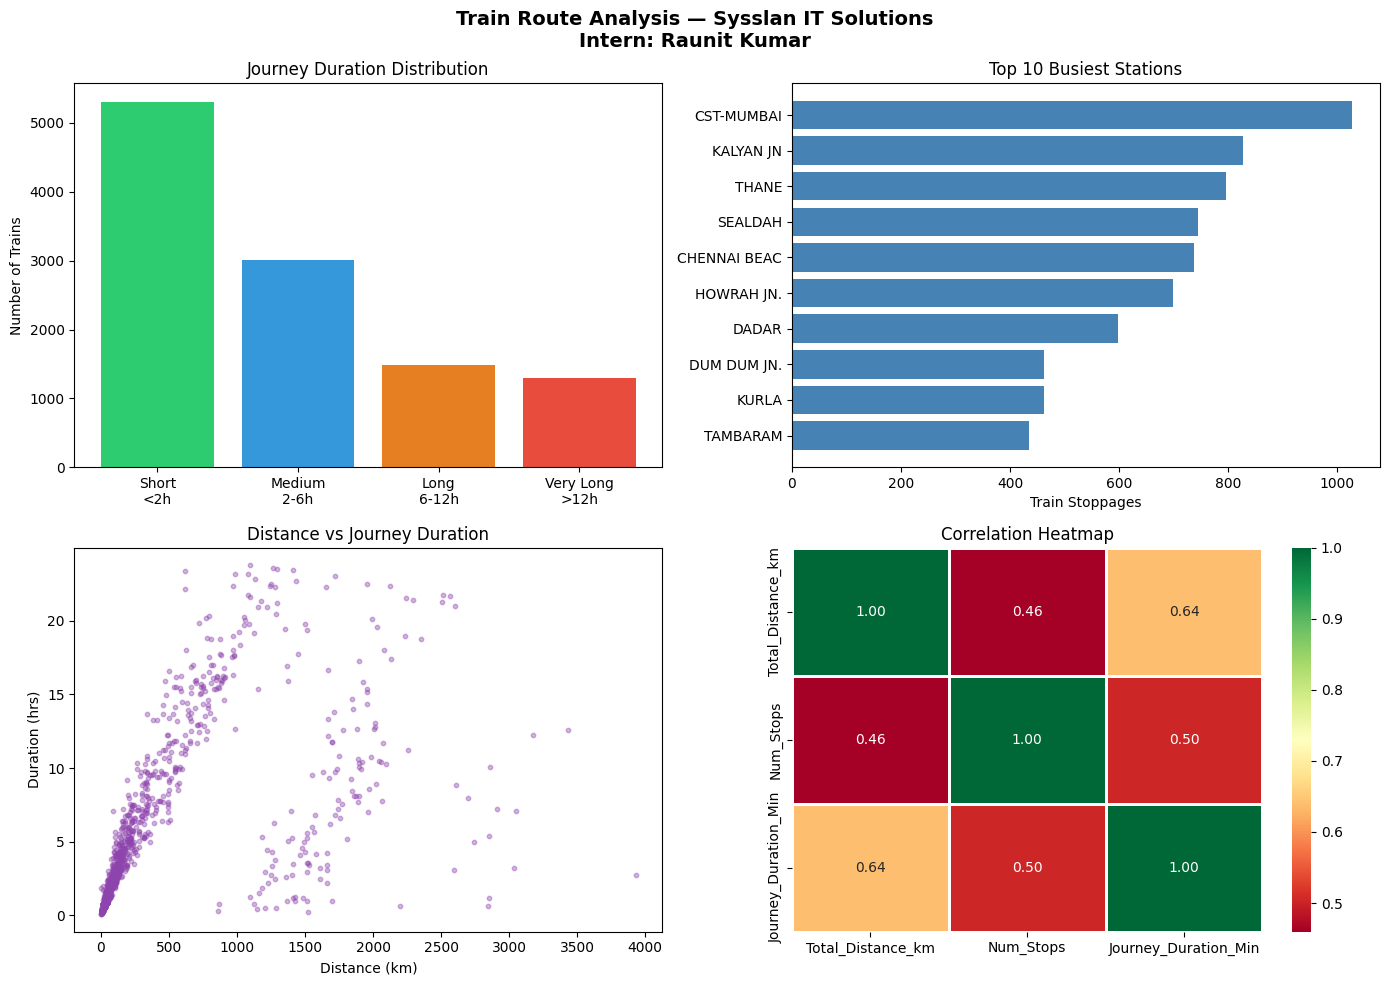

✅ Charts saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Train Route Analysis — Sysslan IT Solutions\nIntern: Raunit Kumar',
             fontsize=14, fontweight='bold')

# Chart 1 - Duration Distribution
train_df['Duration_Category'] = pd.cut(
    train_df['Journey_Duration_Hrs'],
    bins=[0, 2, 6, 12, 24],
    labels=['Short\n<2h', 'Medium\n2-6h', 'Long\n6-12h', 'Very Long\n>12h']
)
cat_counts = train_df['Duration_Category'].value_counts()
axes[0,0].bar(cat_counts.index.astype(str), cat_counts.values,
              color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[0,0].set_title('Journey Duration Distribution')
axes[0,0].set_ylabel('Number of Trains')

# Chart 2 - Top Stations
top_stations = df['Station_Name'].value_counts().head(10)
axes[0,1].barh(top_stations.index[::-1], top_stations.values[::-1], 
               color='steelblue')
axes[0,1].set_title('Top 10 Busiest Stations')
axes[0,1].set_xlabel('Train Stoppages')

# Chart 3 - Distance vs Duration
sample = train_df.sample(1500, random_state=42)
axes[1,0].scatter(sample['Total_Distance_km'], 
                  sample['Journey_Duration_Hrs'],
                  alpha=0.4, s=10, color='#8e44ad')
axes[1,0].set_title('Distance vs Journey Duration')
axes[1,0].set_xlabel('Distance (km)')
axes[1,0].set_ylabel('Duration (hrs)')

# Chart 4 - Correlation Heatmap
corr = train_df[['Total_Distance_km',
                 'Num_Stops',
                 'Journey_Duration_Min']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', 
            ax=axes[1,1], linewidths=2)
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('Level4_Visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Charts saved!")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model_df = train_df[['Total_Distance_km','Num_Stops',
                     'Journey_Duration_Min']].dropna()
X = model_df[['Total_Distance_km','Num_Stops']]
y = model_df['Journey_Duration_Min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)

print(f" Model Trained!")
print(f"Intercept      : {model.intercept_:.2f}")
print(f"Distance coeff : {model.coef_[0]:.4f}")
print(f"Stops coeff    : {model.coef_[1]:.4f}")
print(f"\nMAE  : {mae:.2f} min ({mae/60:.2f} hrs)")
print(f"RMSE : {rmse:.2f} min ({rmse/60:.2f} hrs)")
print(f"R²   : {r2:.4f}")

✅ Model Trained!
Intercept      : 67.59
Distance coeff : 0.2794
Stops coeff    : 6.7137

MAE  : 151.07 min (2.52 hrs)
RMSE : 234.04 min (3.90 hrs)
R²   : 0.4446


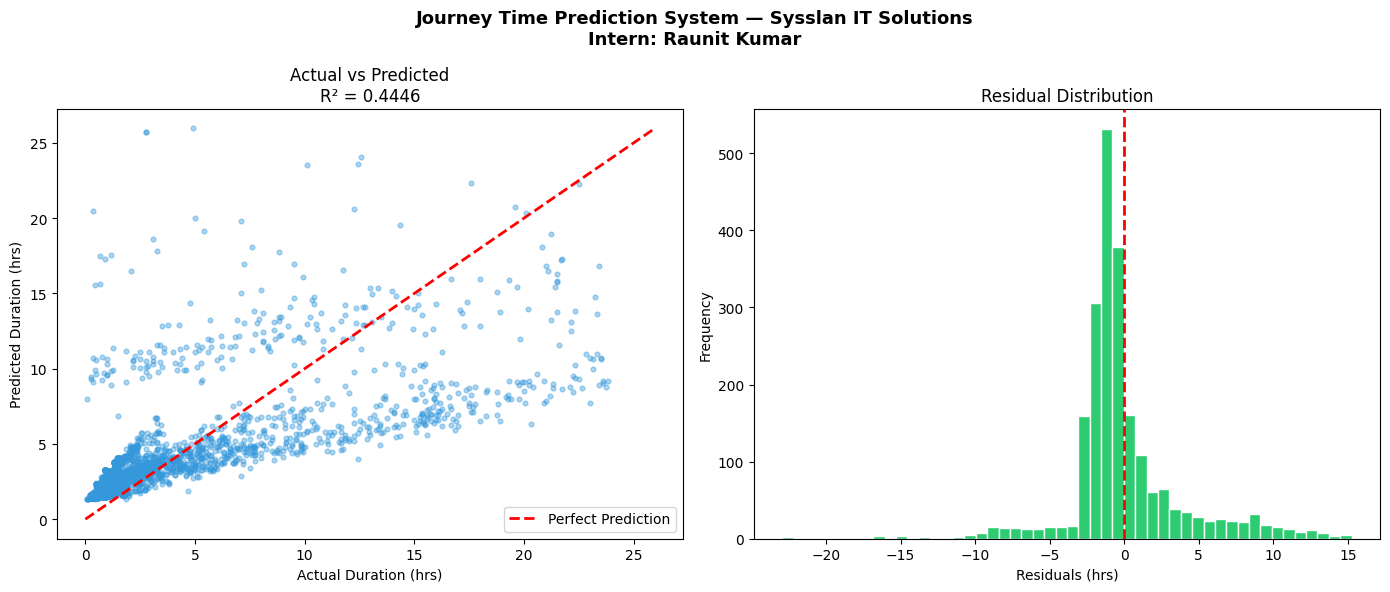

 ALL 6 LEVELS COMPLETE! 


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Journey Time Prediction System — Sysslan IT Solutions\nIntern: Raunit Kumar',
             fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test/60, y_pred/60, 
                alpha=0.4, s=12, color='#3498db')
max_val = max(y_test.max(), y_pred.max()) / 60
axes[0].plot([0, max_val], [0, max_val], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Duration (hrs)')
axes[0].set_ylabel('Predicted Duration (hrs)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}')
axes[0].legend()

# Residuals
residuals = (np.array(y_test) - y_pred) / 60
axes[1].hist(residuals, bins=50, 
             color='#2ecc71', edgecolor='white')
axes[1].axvline(0, color='red', 
                linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (hrs)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('Level6_PredictionSystem.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(" ALL 6 LEVELS COMPLETE! ")